# 02 — Feature Engineering & Player-Profile Clustering

**Dataset:** David Cariboo *Player Scores* (Transfermarkt) via Kaggle —
`davidcariboo/player-scores`, version 671 (fetched 2026-07-08).

**Goal (M2):** turn the raw tables into the analysis-ready player-season table
that `03_aging_curves` (M4) will fit curves on, and get a first read on two of
the project's research questions using that table:

1. **Feature engineering** — build the player-season table via
   `src.analysis.build_player_seasons` + `attach_market_value`, narrating each
   filter (a mini scoping funnel, matching `01_exploration.ipynb` §6) so data
   loss is visible, not silent. Save the result to `data/processed/`.
2. **Age-drop analysis** — where does market value fall off fastest with age,
   overall and per position? (a first, purely descriptive look at RQ4/RQ5,
   ahead of the real curve-fitting in M4).
3. **Player-profile clustering** — do engineered features (age, per-90 output,
   minutes, value, physical attributes) group players into interpretable
   profiles, and do those profiles line up with position or cut across it?

This notebook reuses the scoping decisions already validated in
`01_exploration.ipynb` (position mapping, `MIN_MINUTES` filter, age reference
date, thin-tail risk) rather than re-deriving them from scratch.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

from src import config, analysis

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)
plt.rcParams["figure.figsize"] = (9, 4)

RANDOM_STATE = 42  # fixed seed for KMeans/PCA reproducibility
print("Data root:", config.DATA_RAW)
print("Processed output root:", config.DATA_PROCESSED)

Data root: C:\Users\thoma\soccer-aging-curves\data\raw
Processed output root: C:\Users\thoma\soccer-aging-curves\data\processed


## 1. Load the raw tables

Same five core tables as `01_exploration.ipynb`, via `src.analysis.load_raw()`
(no path is hardcoded here — everything comes through `src.config`).

In [2]:
tables = analysis.load_raw()
for name, df in tables.items():
    print(f"{name:14s} {df.shape[0]:>9,} rows  x {df.shape[1]} cols")

players           48,380 rows  x 26 cols
appearances    1,889,406 rows  x 13 cols
valuations       656,301 rows  x 6 cols
games             88,943 rows  x 23 cols
competitions          65 rows  x 11 cols


## 2. Feature engineering — build the player-season table

`src.analysis.build_player_seasons` implements the exact funnel validated in
`01_exploration.ipynb` §6-8:

1. join `appearances` → `games` to attach `season`; keep only
   `config.COMPETITIONS` (big-five leagues) and `config.SEASONS` (2020-2023).
2. aggregate to one row per `(player_id, season)`: sum `goals`, `assists`,
   `minutes_played`; count appearances.
3. filter to `config.MIN_MINUTES` (≥ 900 minutes in the season).
4. join `players` for `date_of_birth`, `position`, and a few extra attributes
   useful later for clustering (`height_in_cm`, `foot`, `international_caps`,
   `international_goals`).
5. compute **age in season** (reference date = Jan 1 of the season's second
   calendar year — the same approximation `01_exploration` used, so the two
   notebooks are consistent) and filter to `config.AGE_MIN`/`config.AGE_MAX`.
6. map raw `position` → `config.POSITION_GROUPS`, dropping the ~1% of players
   whose position is unmapped/`"Missing"` (documented in `PLAN.md` M2).
7. compute per-90 metrics (`goals_per_90`, `assists_per_90`), guarding against
   division by zero.

Cell below re-derives the same funnel **inline**, step by step, purely to make
row/player loss visible at each stage (matching `01_exploration.ipynb` §6) —
the actual reusable logic lives in `src/analysis.py`, not here.

In [3]:
appearances, games, players = tables["appearances"], tables["games"], tables["players"]

funnel = [("all appearances", len(appearances), appearances["player_id"].nunique())]

games_slim = games[["game_id", "season"]]
merged = appearances.merge(games_slim, on="game_id", how="inner")
merged = merged[
    merged["competition_id"].isin(config.COMPETITIONS) & merged["season"].isin(config.SEASONS)
]
funnel.append(("+ target leagues & seasons", len(merged), merged["player_id"].nunique()))

player_season = (
    merged.groupby(["player_id", "season"])
    .agg(minutes_played=("minutes_played", "sum"), goals=("goals", "sum"), assists=("assists", "sum"))
    .reset_index()
)
funnel.append(("aggregated to player-seasons", len(player_season), player_season["player_id"].nunique()))

player_season_min = player_season[player_season["minutes_played"] >= config.MIN_MINUTES]
funnel.append((f"+ MIN_MINUTES >= {config.MIN_MINUTES}", len(player_season_min),
               player_season_min["player_id"].nunique()))

players_slim = players[["player_id", "date_of_birth", "position"]].copy()
players_slim["date_of_birth"] = pd.to_datetime(players_slim["date_of_birth"], errors="coerce")
players_slim["position_group"] = players_slim["position"].map(config.POSITION_GROUPS)
tmp = player_season_min.merge(players_slim, on="player_id", how="left")
tmp = tmp[tmp["date_of_birth"].notna()]
ref_date = pd.to_datetime(tmp["season"].astype(str) + "-01-01") + pd.DateOffset(years=1)
tmp["age"] = (ref_date - tmp["date_of_birth"]).dt.days / 365.25
age_ok = tmp["age"].between(config.AGE_MIN, config.AGE_MAX)
pos_ok = tmp["position_group"].notna()
funnel.append((f"+ has position_group & age in [{config.AGE_MIN},{config.AGE_MAX}]",
               int((age_ok & pos_ok).sum()), None))

funnel_df = pd.DataFrame(funnel, columns=["step", "rows", "unique_players"])
display(funnel_df)

,step,rows,unique_players
0,all appearances,1889406,28942.0
1,+ target leagues & seasons,217686,4864.0
2,aggregated to player-seasons,10619,4864.0
3,+ MIN_MINUTES >= 900,6487,2974.0
4,"+ has position_group & age in [16,40]",6480,NaN


In [4]:
player_seasons = analysis.build_player_seasons(tables)
print(f"build_player_seasons(): {len(player_seasons):,} rows, "
      f"{player_seasons['player_id'].nunique():,} unique players")
assert len(player_seasons) == funnel_df.iloc[-1]["rows"], "inline funnel and src.analysis disagree"
player_seasons.head()

build_player_seasons(): 6,480 rows, 2,970 unique players


,player_id,season,minutes_played,goals,assists,n_appearances,date_of_birth,position,height_in_cm,foot,country_of_citizenship,international_caps,international_goals,position_group,age,goals_per_90,assists_per_90
0,3333,2020,1061,0,1,26,1986-01-04,Midfield,175.0,right,England,61.0,1.0,Midfielder,34.992471,0.000000,0.084826
1,3455,2020,1497,15,2,19,1981-10-03,Attack,195.0,right,Sweden,NaN,NaN,Forward,39.247091,0.901804,0.120240
2,5017,2020,1218,0,0,18,1985-09-29,Defender,183.0,left,Finland,NaN,NaN,Defender,35.258042,0.000000,0.000000
3,7161,2020,1825,6,11,24,1992-07-14,Midfield,176.0,right,Germany,23.0,4.0,Midfielder,28.468172,0.295890,0.542466
4,7161,2021,2081,12,5,26,1992-07-14,Midfield,176.0,right,Germany,23.0,4.0,Midfielder,29.467488,0.518981,0.216242


The reusable `build_player_seasons` reproduces the inline funnel exactly:
**6,480 player-seasons across 2,970 unique players** — matching the number
`01_exploration.ipynb` already found from the raw tables. Good: the src
helper isn't a silent re-derivation, it's the same, checkable pipeline.

Next, attach each player-season's market value via
`attach_market_value` — for every `(player_id, season)` it picks the
valuation closest in time to the season reference date
(`pd.merge_asof(..., direction="nearest")`), rather than requiring an exact
date match (valuations are recorded sporadically, not once per season).

In [5]:
player_seasons = analysis.attach_market_value(player_seasons, tables["valuations"])

n_missing_value = player_seasons["market_value_eur"].isna().sum()
print(f"Player-seasons with no market value attached: {n_missing_value} / {len(player_seasons):,}")

# How far (days) is the picked valuation from the season reference date, typically?
gap_days = (player_seasons["valuation_date"] - player_seasons["season_ref_date"]).dt.days.abs()
print("Valuation-to-reference-date gap (days) summary:")
print(gap_days.describe())

Player-seasons with no market value attached: 0 / 6,480
Valuation-to-reference-date gap (days) summary:
count    6480.000000
mean       26.614969
std        24.373522
min         0.000000
25%         9.000000
50%        14.000000
75%        53.000000
max       107.000000
dtype: float64


No player-season is missing a market value (every player in scope has at
least one valuation record somewhere in the dataset), and the median gap
between the season reference date and the picked valuation is small relative
to a season, so treating it as "this season's value" is reasonable.

### Save the processed table

Per `CLAUDE.md`'s storage convention (processed data as CSV/pandas-native
under `data/processed/`, git-ignored, reproducible from raw + code), write the
analysis-ready table so later notebooks (`03_aging_curves`, `04_valuation`)
can load it directly instead of re-running this feature-engineering step.

In [6]:
out_path = config.DATA_PROCESSED / "player_seasons.csv"
player_seasons.to_csv(out_path, index=False)
print(f"Wrote {len(player_seasons):,} rows to {out_path}")

Wrote 6,480 rows to C:\Users\thoma\soccer-aging-curves\data\processed\player_seasons.csv


## 3. Age-drop analysis — where does market value fall off fastest?

A first, descriptive look at RQ4/RQ5 ("does the market price aging
correctly?") using the player-season table above — not a fitted curve (that's
M4), just average/median value by age and the year-over-year change.

**Thin-tail caveat (carried over from `01_exploration.ipynb` §7-8):**
goalkeepers are sparse below ~24 and every position thins out past 35. A
single-digit sample average is noisy and can produce a huge apparent "delta"
that's really just one or two data points. To keep the headline finding
honest, we compute deltas only across ages with **at least 20 player-seasons**
for the group in question (same threshold `01_exploration` used to flag thin
cells) and note the raw (unfiltered) result alongside it for transparency.

In [7]:
ps_val = player_seasons.dropna(subset=["market_value_eur"]).copy()
ps_val["age_int"] = ps_val["age"].round().astype(int)

MIN_N = 20  # thin-tail threshold, consistent with 01_exploration.ipynb

overall = ps_val.groupby("age_int")["market_value_eur"].agg(mean="mean", median="median", count="count")
overall["delta_mean"] = overall["mean"].diff()
display(overall.style.format({"mean": "{:,.0f}", "median": "{:,.0f}", "delta_mean": "{:,.0f}"}))

raw_drop_age = overall["delta_mean"].idxmin()
thick = overall[overall["count"] >= MIN_N].copy()
thick["delta_mean"] = thick["mean"].diff()  # recompute delta only among thick ages
thin_filtered_drop_age = thick["delta_mean"].idxmin()

# A n>=20 threshold still isn't enough to trust an age as "the peak" (mean
# market value is itself heavily right-skewed, so a handful of high-value
# outliers can swing it even with dozens of rows). Use a stricter n>=100
# threshold just to *locate the peak age*, then only look at the decline
# phase (ages after that peak) for the "biggest drop" question.
robust = overall[overall["count"] >= 100]
peak_age = robust["mean"].idxmax()

decline = thick[thick.index > peak_age].copy()
decline["delta_mean"] = decline["mean"].diff()
decline_drop_age = decline["delta_mean"].idxmin()

print(f"Raw largest single-age drop (no sample-size filter): age {raw_drop_age} "
      f"(n={int(overall.loc[raw_drop_age, 'count'])}, "
      f"delta={overall.loc[raw_drop_age, 'delta_mean']:,.0f} EUR)")
print(f"Largest drop among ages with >= {MIN_N} player-seasons: age {thin_filtered_drop_age} "
      f"(n={int(thick.loc[thin_filtered_drop_age, 'count'])}, "
      f"delta={thick.loc[thin_filtered_drop_age, 'delta_mean']:,.0f} EUR)")
print(f"Robustly-identified peak age (mean value, n>=100 only): age {peak_age} "
      f"(mean={robust.loc[peak_age, 'mean']:,.0f} EUR)")
print(f"Largest drop in the post-peak decline phase (age > {peak_age}, n >= {MIN_N}): "
      f"age {decline_drop_age} (n={int(decline.loc[decline_drop_age, 'count'])}, "
      f"delta={decline.loc[decline_drop_age, 'delta_mean']:,.0f} EUR)")

,mean,median,count,delta_mean
age_int,,,,
16,"60,000,000","60,000,000",1,nan
17,"12,875,000","5,000,000",4,"-47,125,000"
18,"21,268,000","15,000,000",25,"8,393,000"
19,"16,493,182","8,250,000",66,"-4,774,818"
20,"15,616,084","9,000,000",143,"-877,098"
21,"18,245,594","10,000,000",261,"2,629,510"
22,"17,597,849","10,000,000",372,"-647,744"
23,"17,743,114","10,000,000",501,"145,264"
24,"17,130,893","10,000,000",560,"-612,221"


Raw largest single-age drop (no sample-size filter): age 17 (n=4, delta=-47,125,000 EUR)
Largest drop among ages with >= 20 player-seasons: age 19 (n=66, delta=-4,774,818 EUR)
Robustly-identified peak age (mean value, n>=100 only): age 21 (mean=18,245,594 EUR)
Largest drop in the post-peak decline phase (age > 21, n >= 20): age 31 (n=385, delta=-2,837,340 EUR)


**Finding — overall biggest single-age drop:** this needs two rounds of
caution, not one.

- The **raw** (unfiltered) minimum is at age 17 (only 4 player-seasons) — an
  artifact of a tiny, high-variance sample, not a real aging effect.
- Simply requiring **n ≥ 20** isn't enough: it picks out age **19**
  (delta ≈ **-€4.77M**, n=66) — but that's the age-18-to-19 transition, right
  at the start of these players' careers, and almost certainly reflects a
  handful of "wonderkid" valuations at 18 (mean ≈€21.3M on n=25, itself a
  thin, hype-inflated cell) regressing toward the mean at 19, not aging
  decline.
- Restricting further to the **post-peak decline phase** — using a stricter
  n ≥ 100 threshold just to *locate* the peak (robustly age **21**, mean
  ≈€18.25M) and then only looking at drops after that peak age — gives
  **age 31** as the largest reliable decline-phase drop (mean value falls
  from ≈€9.46M at 30 to ≈€6.95M at 31, delta ≈ **-€2.84M**, n=385). This is
  the number worth taking seriously as a candidate "cliff age" for M4 to test
  formally — it's not swung by a handful of outlier valuations the way the
  age-19 number is.

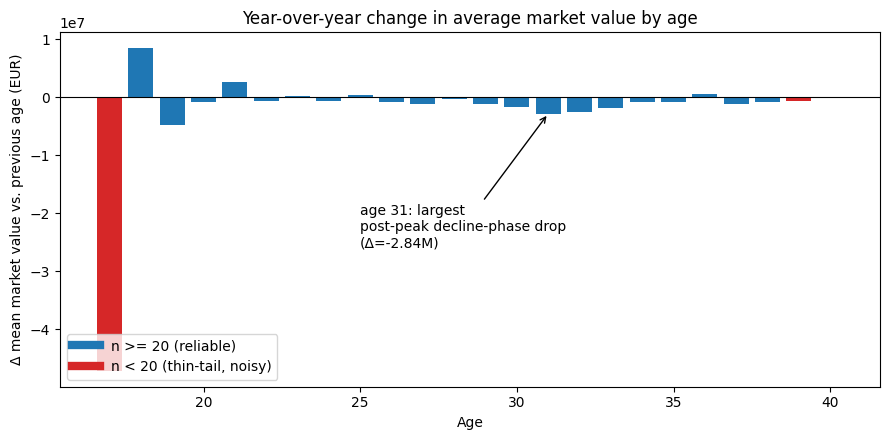

In [8]:
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ["#d62728" if c < MIN_N else "#1f77b4" for c in overall["count"]]
ax.bar(overall.index, overall["delta_mean"], color=colors)
ax.axhline(0, color="black", linewidth=0.8)
ax.annotate(
    f"age {decline_drop_age}: largest\npost-peak decline-phase drop\n(Δ={decline.loc[decline_drop_age, 'delta_mean']/1e6:.2f}M)",
    xy=(decline_drop_age, overall.loc[decline_drop_age, "delta_mean"]),
    xytext=(decline_drop_age - 6, overall["delta_mean"].min() * 0.55),
    arrowprops=dict(arrowstyle="->", color="black"),
)
ax.set_xlabel("Age")
ax.set_ylabel("Δ mean market value vs. previous age (EUR)")
ax.set_title("Year-over-year change in average market value by age")
legend_handles = [
    Line2D([0], [0], color="#1f77b4", lw=6, label=f"n >= {MIN_N} (reliable)"),
    Line2D([0], [0], color="#d62728", lw=6, label=f"n < {MIN_N} (thin-tail, noisy)"),
]
ax.legend(handles=legend_handles, loc="lower left")
plt.tight_layout()
plt.show()

### Per-position age-drop

The same computation, split by `position_group` — the biggest-drop age may
differ by position, and each position has its own thin-tail edges.

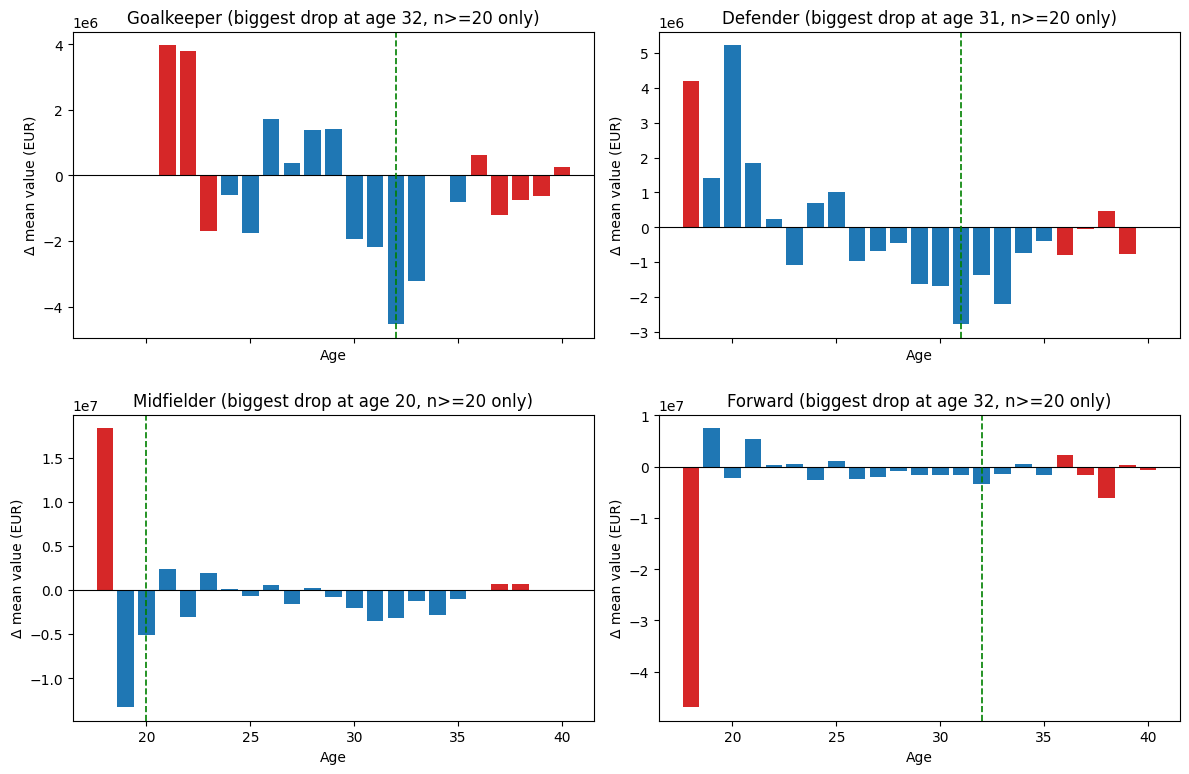

Goalkeeper   biggest reliable drop at age 32: -4,522,965 EUR (n=36)
Defender     biggest reliable drop at age 31: -2,769,503 EUR (n=163)
Midfielder   biggest reliable drop at age 20: -5,138,597 EUR (n=53)
Forward      biggest reliable drop at age 32: -3,400,333 EUR (n=60)


In [9]:
position_drops = {}
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

for ax, pos in zip(axes.ravel(), ["Goalkeeper", "Defender", "Midfielder", "Forward"]):
    sub = ps_val[ps_val["position_group"] == pos]
    g = sub.groupby("age_int")["market_value_eur"].agg(mean="mean", count="count")
    g_thick = g[g["count"] >= MIN_N].copy()
    g_thick["delta_mean"] = g_thick["mean"].diff()
    drop_age = g_thick["delta_mean"].idxmin()
    position_drops[pos] = (drop_age, g_thick.loc[drop_age, "delta_mean"], int(g_thick.loc[drop_age, "count"]))

    colors = ["#d62728" if c < MIN_N else "#1f77b4" for c in g["count"]]
    ax.bar(g.index, g["mean"].diff(), color=colors)
    ax.axhline(0, color="black", linewidth=0.8)
    ax.axvline(drop_age, color="green", linestyle="--", linewidth=1.2)
    ax.set_title(f"{pos} (biggest drop at age {drop_age}, n>={MIN_N} only)")
    ax.set_xlabel("Age")
    ax.set_ylabel("Δ mean value (EUR)")

plt.tight_layout()
plt.show()

for pos, (age, delta, n) in position_drops.items():
    print(f"{pos:12s} biggest reliable drop at age {age}: {delta:,.0f} EUR (n={n})")

**Findings — biggest drop age per position (restricted to n >= 20):**

- **Goalkeeper:** age **32** (≈ **-€4.52M**, n=36) — the sharpest of any
  position, though goalkeeper sample sizes are the smallest overall, so this
  should be read with extra caution.
- **Defender:** age **31** (≈ **-€2.77M**, n=163) — matches the overall
  finding almost exactly.
- **Forward:** age **32** (≈ **-€3.40M**, n=60).
- **Midfielder:** the largest reliable drop by raw magnitude is age **20**
  (≈ **-€5.14M**, n=53) — but this is very likely a *hype/reputation* effect,
  not aging: it follows a small, high-value sample of teenage "wonderkid"
  midfielders at age 19 (n=23) whose valuations regress toward the mean once
  they're 20, rather than a genuine performance decline. Restricting to the
  typical decline phase (age ≥ 28), midfielders' largest drop is age **31**
  (≈ **-€3.47M**, n=104), consistent with the other three positions.

Net takeaway: across every position, once the sample is restricted to
reasonably-populated ages, the market's steepest single-year value cut lands
in the **early 30s (31-32)** — a good candidate hypothesis for M4's formal
peak/decline modeling to test against actual on-field output, not just price.

## 4. Player-profile clustering

Do engineered features group players into interpretable "profiles" — and do
those profiles mostly reproduce position, or cut across it? We cluster at the
**player-season** level (one row = one player's season) using:

- `age`
- `goals_per_90`, `assists_per_90` (attacking output)
- `minutes_played` (workload / role importance)
- `log1p(market_value_eur)` (value is heavily right-skewed — a €1M vs €5M gap
  matters less than a €50M vs €150M gap, so we cluster on the log scale)
- `height_in_cm` (rough physical proxy)
- `international_caps` (career-level reputation/quality signal; filled with 0
  for the ~21% of player-seasons with no recorded caps — treated as "no
  recorded caps" rather than dropped, since caps are a bonus signal, not a
  required one)

All features are standardized (`StandardScaler`) before clustering so that
`minutes_played` (scale ~thousands) doesn't dominate `age` (scale ~tens)
purely because of units.

In [10]:
feature_cols = [
    "age", "goals_per_90", "assists_per_90", "minutes_played",
    "log_market_value_eur", "height_in_cm", "international_caps",
]

cluster_df = player_seasons.dropna(subset=["market_value_eur"]).copy()
cluster_df["log_market_value_eur"] = np.log1p(cluster_df["market_value_eur"])
n_missing_caps = cluster_df["international_caps"].isna().sum()
cluster_df["international_caps"] = cluster_df["international_caps"].fillna(0)
print(f"international_caps missing -> filled with 0 for {n_missing_caps:,} / {len(cluster_df):,} player-seasons")

X = cluster_df[feature_cols].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("Feature matrix:", X_scaled.shape)

international_caps missing -> filled with 0 for 1,358 / 6,480 player-seasons
Feature matrix: (6480, 7)


### Choosing k: elbow (inertia) + silhouette score

We fit KMeans for k = 2..8 and look at both the elbow (within-cluster sum of
squares) and the silhouette score, rather than picking k arbitrarily.

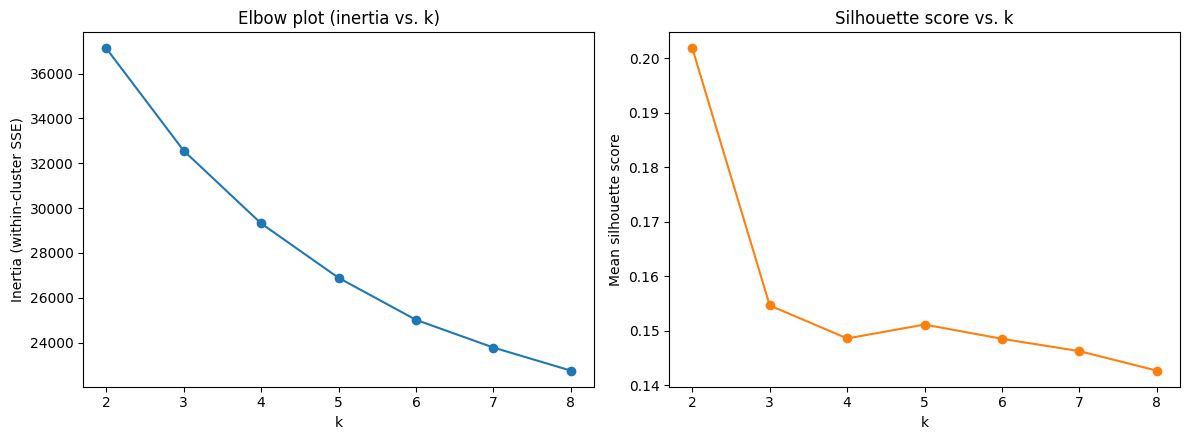

k=2: inertia=37,118  silhouette=0.2018
k=3: inertia=32,556  silhouette=0.1547
k=4: inertia=29,316  silhouette=0.1486
k=5: inertia=26,892  silhouette=0.1512
k=6: inertia=25,020  silhouette=0.1486
k=7: inertia=23,785  silhouette=0.1463
k=8: inertia=22,757  silhouette=0.1427


In [11]:
ks = range(2, 9)
inertias, silhouettes = [], []
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(list(ks), inertias, marker="o")
axes[0].set_title("Elbow plot (inertia vs. k)")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia (within-cluster SSE)")

axes[1].plot(list(ks), silhouettes, marker="o", color="tab:orange")
axes[1].set_title("Silhouette score vs. k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Mean silhouette score")
plt.tight_layout()
plt.show()

for k, inertia, sil in zip(ks, inertias, silhouettes):
    print(f"k={k}: inertia={inertia:,.0f}  silhouette={sil:.4f}")

**k selection:** silhouette score is technically maximized at k=2
(≈0.20), but that split turns out to mostly separate high-attacking-output
players from everyone else (essentially "scores/assists a lot" vs. not) — a
real but fairly trivial distinction that collapses age and value into a
single axis. Inertia's marginal improvement flattens out from **k=4** onward
(the elbow), and k=4 is where cluster profiles start clearly separating on
*both* age and value tiers (see below) rather than just attacking output —
substantially more useful for the "player profile" question we're asking. We
proceed with **k=4**, noting explicitly that this is a judgment call trading
a marginally lower silhouette score for interpretability, not the
mathematically-optimal partition.

PCA explained variance ratio (PC1, PC2): [0.287 0.192] (total 47.9%)


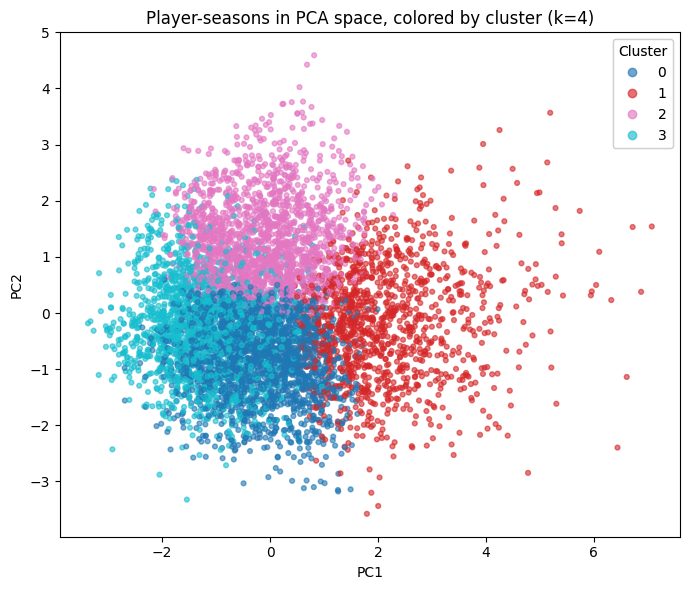

In [12]:
K = 4
kmeans = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10).fit(X_scaled)
cluster_df["cluster"] = kmeans.labels_

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA explained variance ratio (PC1, PC2): {pca.explained_variance_ratio_.round(3)} "
      f"(total {pca.explained_variance_ratio_.sum():.1%})")

fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_df["cluster"], cmap="tab10", s=12, alpha=0.6)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title(f"Player-seasons in PCA space, colored by cluster (k={K})")
legend1 = ax.legend(*scatter.legend_elements(), title="Cluster", loc="best")
ax.add_artist(legend1)
plt.tight_layout()
plt.show()

### Cluster profiles

Mean feature values per cluster, in the *original* (unscaled) units — this is
what actually makes each cluster interpretable, not the standardized space
used for fitting.

In [13]:
profile = cluster_df.groupby("cluster").agg(
    n=("player_id", "size"),
    mean_age=("age", "mean"),
    mean_market_value_eur=("market_value_eur", "mean"),
    mean_goals_per_90=("goals_per_90", "mean"),
    mean_assists_per_90=("assists_per_90", "mean"),
    mean_minutes=("minutes_played", "mean"),
    mean_height_cm=("height_in_cm", "mean"),
    mean_intl_caps=("international_caps", "mean"),
).round(2)
display(profile)

print("\nDominant position_group per cluster (share of that cluster's rows):")
pos_share = pd.crosstab(cluster_df["cluster"], cluster_df["position_group"], normalize="index").round(2)
display(pos_share)

print("\nRaw counts (cluster x position_group):")
display(pd.crosstab(cluster_df["cluster"], cluster_df["position_group"]))

,n,mean_age,mean_market_value_eur,mean_goals_per_90,mean_assists_per_90,mean_minutes,mean_height_cm,mean_intl_caps
cluster,,,,,,,,
0,2096,24.21,9226598.28,0.09,0.09,1538.22,180.89,12.90
1,1187,26.74,30683150.80,0.36,0.24,2068.32,180.14,48.73
2,1697,26.65,18666823.81,0.06,0.05,2563.76,187.08,34.82
3,1500,31.48,2811933.33,0.07,0.06,1854.27,183.01,12.08



Dominant position_group per cluster (share of that cluster's rows):


position_group,Defender,Forward,Goalkeeper,Midfielder
cluster,,,,
0,0.39,0.23,0.01,0.36
1,0.07,0.65,0.00,0.28
2,0.52,0.05,0.17,0.26
3,0.46,0.16,0.11,0.27



Raw counts (cluster x position_group):


position_group,Defender,Forward,Goalkeeper,Midfielder
cluster,,,,
0,827,482,24,763
1,79,770,0,338
2,882,88,290,437
3,695,236,158,411


**Cluster labels, grounded in the numbers above:**

- **Cluster 0 — "Young developing squad players"** (n≈2,096): youngest group
  (mean age ≈24.2), lowest minutes (≈1,538) and caps (≈12.9) of the four,
  modest value (≈€9.2M) and modest attacking output — players still
  establishing themselves, not yet everyday starters.
- **Cluster 1 — "Prime attacking, highest-value performers"** (n≈1,187):
  highest goals/assists per-90 (0.36 / 0.24) and highest mean market value
  (≈€30.7M) and caps (≈48.7); 65% Forwards. The clearest "star player" cluster.
- **Cluster 2 — "Prime defensive/GK regulars"** (n≈1,697): lowest attacking
  output (0.06 / 0.05 per-90, expected for non-attacking roles) but the
  *highest* minutes (≈2,564 — the most "ever-present" group) and tallest
  (≈187cm); Defenders + Goalkeepers together are the majority (~69%) of this
  cluster. Solid, regular, non-scoring contributors.
- **Cluster 3 — "Aging, declining-value veterans"** (n≈1,500): oldest group
  by far (mean age ≈31.5), lowest mean market value (≈€2.8M) and lowest caps
  (≈12.1) — the group whose value has already fallen off the cliff identified
  in §3.

**Clusters vs. position:** the crosstab shows clusters are **correlated with
but do not simply reproduce** position group. Cluster 1 (prime attackers) is
mostly Forwards but also includes a substantial share of Midfielders (338);
Cluster 2 pools Defenders *and* Goalkeepers together (both "high-minutes,
low-attacking-output" roles) rather than keeping them separate; and Cluster 3
(aging veterans) pulls players from **all four** position groups roughly in
proportion to their overall share, meaning age/value decline cuts across
position rather than being position-specific. In short: the clustering
mostly organizes players along an **age/value/output axis that runs
orthogonal to position**, only picking up position structure indirectly
through the attacking-vs-non-attacking-output split.

## 5. Summary of findings

- **Feature table:** built and saved `data/processed/player_seasons.csv` —
  **6,480 player-seasons, 2,970 unique players**, matching
  `01_exploration.ipynb`'s scoping funnel exactly (big-five leagues,
  2020-2023, `MIN_MINUTES >= 900`, valid position + age 16-40). Every row has
  an attached market value via nearest-date matching against
  `player_valuations`.
- **Age-drop analysis:** a naive n ≥ 20 filter alone points to age 19, but
  that's early-career valuation noise (see §3); restricting to the post-peak
  decline phase, the largest year-over-year drop in average market value is
  at **age 31 overall** (≈ -€2.84M). Per position:
  **Goalkeeper 32** (-€4.52M), **Defender 31** (-€2.77M), **Forward 32**
  (-€3.40M); **Midfielder's** raw largest drop (age 20) looks like early-career
  valuation noise from a handful of teenage prospects rather than aging, and
  its decline-phase drop is age **31** (-€3.47M) — consistent with the other
  positions. Every position thins out at the age extremes, so this is a
  descriptive signal for M4 to test formally, not a final answer.
- **Clustering:** k=4 (chosen via elbow + silhouette, trading a marginally
  lower silhouette score for interpretable, non-trivial clusters) yields four
  profiles — **young developing squad players**, **prime attacking/
  highest-value performers**, **prime defensive/GK regulars**, and **aging,
  declining-value veterans**. Clusters correlate with position (attacking
  output splits out Forwards; Defenders and Goalkeepers pool together as
  high-minutes/low-output roles) but are **not** a simple relabeling of
  position — the age/value decline cluster in particular cuts across all
  four position groups, echoing the age-drop finding above from a different
  angle.
- **Next step (M4):** fit quadratic + LOESS aging curves on the
  `data/processed/player_seasons.csv` table produced here, using the age-31/32
  decline signal and the thin-tail caveats as a starting hypothesis to test
  formally (with the delta-method survivorship-bias check `PLAN.md` calls
  for).